# Photovoltaic efficiency calculations

First, we import and then instantiate the class ```Efficiency``` which loads the ```csv``` file containing the solar data

In [1]:
from SLME import Efficiency

In [2]:
eff = Efficiency()

Now, there are three ways we can calculate a photovoltaic efficiency, which we will do using the function ```calculate()```

First we need some data: provided in this directory is a file ```example_data.json``` which contains band-gap and absorption spectrum data for GaAs and Sb2Se3 from a dataset calculated by Fabini et al. (2019), available through the MPContribs API under the project name ```Screening Inorganic PV```

In [3]:
import json
with open('example_data.json') as file:
    data = json.load(file)
GaAs_data = data['GaAs']
Sb2Se3_data = data['Sb2Se3']

In [4]:
GaAs_energies = GaAs_data['energies']
GaAs_alphas = GaAs_data['alphas']
GaAs_gap = GaAs_data['band_gap']
GaAs_del_E = GaAs_data['del_E']
Sb2Se3_energies = Sb2Se3_data['energies']
Sb2Se3_alphas = Sb2Se3_data['alphas']
Sb2Se3_gap = Sb2Se3_data['band_gap']
Sb2Se3_del_E = GaAs_data['del_E']

We can have a look at these absorption spectra and where the band-gaps lie relative to the onset of absorption:

Text(0, 0.5, '$\\alpha \\text{cm}^{-1}$')

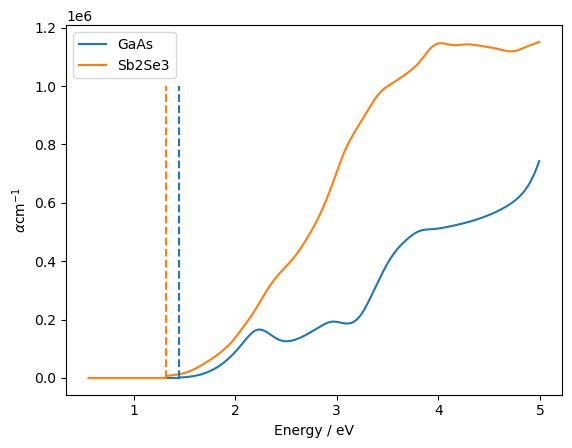

In [5]:
import matplotlib.pyplot as plt
plt.plot(GaAs_energies,GaAs_alphas,label='GaAs')
plt.plot(Sb2Se3_energies,Sb2Se3_alphas,label='Sb2Se3')
plt.vlines(x=GaAs_gap,ymin=0,ymax=1E6,linestyles='dashed',color='tab:blue')
plt.vlines(x=Sb2Se3_gap,ymin=0,ymax=1E6,linestyles='dashed',color='tab:orange')
plt.legend()
plt.xlabel('Energy / eV')
plt.ylabel(r'$\alpha \text{cm}^{-1}$')

We can also plot the absorptance, typically calculated using a Beer-Lambert approximation (exponential attentuation of intensity with thickness of absorber). We will assume a thickness of 500 nm (the default value for the thickness, ```d``` in the code)

Text(0, 0.5, 'Absorptance')

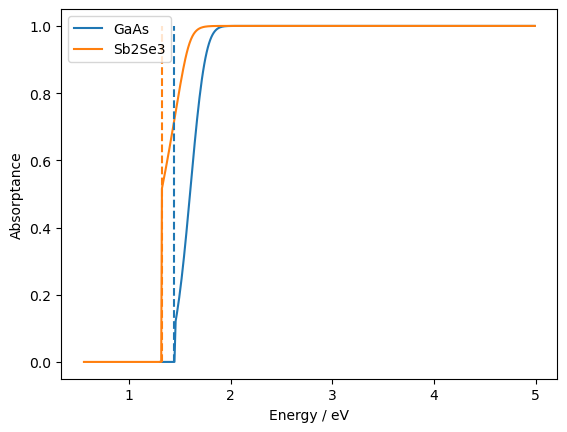

In [6]:
import numpy as np
GaAs_absorptance  = 1 - np.exp(-2*np.array(GaAs_alphas)*500E-7)
Sb2Se3_absorptance  = 1 - np.exp(-2*np.array(Sb2Se3_alphas)*500E-7)
plt.plot(GaAs_energies,GaAs_absorptance,label='GaAs')
plt.plot(Sb2Se3_energies,Sb2Se3_absorptance,label='Sb2Se3')
plt.vlines(x=GaAs_gap,ymin=0,ymax=1,linestyles='dashed',color='tab:blue')
plt.vlines(x=Sb2Se3_gap,ymin=0,ymax=1,linestyles='dashed',color='tab:orange')
plt.legend()
plt.xlabel('Energy / eV')
plt.ylabel('Absorptance')

We can see how these curves differ from the step-function at the band-gap that the detailed balance limit assumes

## Absorption spectrum

In the simplest case, we can now calculate an SLME using our absorption data and ```del_E```s:

In [7]:
GaAs_SLME = eff.calculate(energies = GaAs_energies, alphas = GaAs_alphas,del_E=GaAs_del_E)
Sb2Se3_SLME = eff.calculate(energies = Sb2Se3_energies, alphas = Sb2Se3_alphas,del_E=Sb2Se3_del_E)

In [8]:
print("The estimated SLMEs for GaAs and Sb2Se3 at 300 K and for a thickness of 500nm are")
print(f"GaAs: {GaAs_SLME} %")
print(f"Sb2Se3: {Sb2Se3_SLME} %")

The estimated SLMEs for GaAs and Sb2Se3 at 300 K and for a thickness of 500nm are
GaAs: 28.29757708994315 %
Sb2Se3: 31.442812657490354 %


Note that, by default, the temperature and thickness are set to the traditional values of 300 K and 500 nm, respectively. This can be changed by changing the arguments ```T``` and ```d```. Note the units of ```d``` are nm.

For instance, we could investigate how efficiency changes with respect to thickness

Text(0.5, 1.0, 'SLME vs thickness for GaAS')

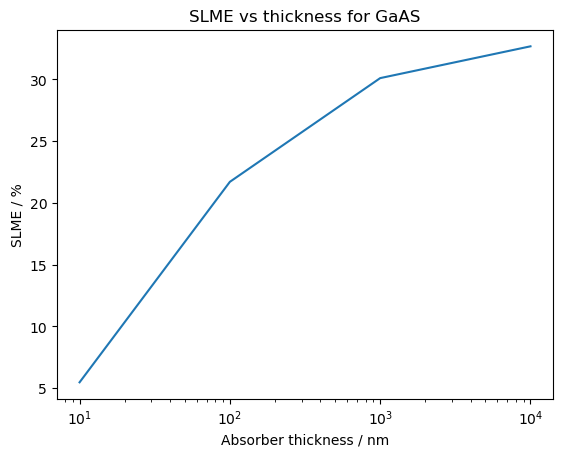

In [9]:
SLMEs = []
ds = [10,100,1000,10000]
for d in ds:
    SLMEs.append(eff.calculate(energies = GaAs_energies, alphas = GaAs_alphas,del_E=GaAs_del_E,d=d))
plt.plot(ds,SLMEs)
plt.xscale('log')
plt.xlabel('Absorber thickness / nm')
plt.ylabel('SLME / %')
plt.title('SLME vs thickness for GaAS')

## Absorptance spectrum

If we want to use absorptance rather than absorption data, set ```Absorptance=True```. We can use this to, for example, see what the detailed balance approach would give us as an efficiency

First let's define a step-function generator:

In [10]:
def step(energies,gap):
    As = []
    for E in energies:
        if E>=gap:
            As.append(1)
        else:
            As.append(0)
    return As

In [11]:
Es = np.linspace(0,5,100)

In [12]:
SQ_GaAs_As = step(Es,GaAs_gap)

In [13]:
GaAs_SQ_PCE = eff.calculate(Es, SQ_GaAs_As, absorptance = True)

In [14]:
GaAs_SQ_PCE

32.81161355863712

Significantly larger than our SLME for 500nm thickness, and should be the limit our thickness plot converges to

## Optional settings

We get a more in-depth answer by setting ```display=True```

In [15]:
GaAs_SLME_2 =eff.calculate(energies = GaAs_energies, alphas = GaAs_alphas,del_E=GaAs_del_E,display=True)

Maximum predicted efficiency of 28.3% corresponding to a power of 282.86 W/m^2, short-circuit current density of 255.81 A/m^2 and voltage of 1.13 V under AM1.5G illumination at 300 K for a 500 nm material


We get these optimal properties as a list [power, voltage, current density, efficiency]  by setting ```return_PVJ=True```

In [16]:
eff.calculate(energies = GaAs_energies, alphas = GaAs_alphas,del_E=GaAs_del_E,return_PVJ=True)

(282.8567326583944, 1.1309999999999862, 255.8125815368344, 28.29757708994315)

We can also understand the trade-off of voltage and current by setting ```JV_plot=True```

28.29757708994315

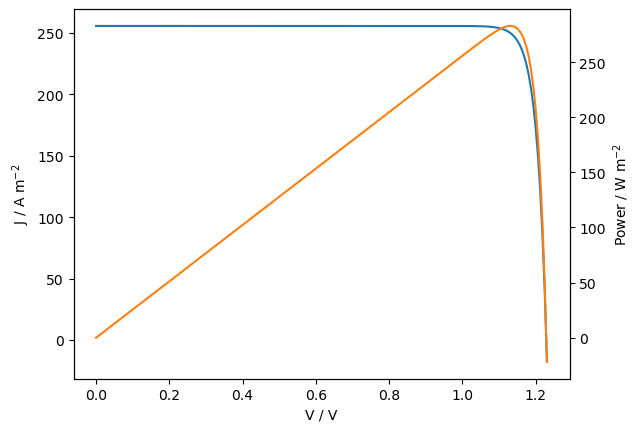

In [17]:
eff.calculate(energies = GaAs_energies, alphas = GaAs_alphas,del_E=GaAs_del_E,JV_plot=True)

This plot is automatically saved as ```JV_plot.svg```